<a href="https://colab.research.google.com/github/adelinda02/UTS-ANALISIS-DAN-VISUALISASI-DATA/blob/main/P4_uts_analisis_dan_visualisasi_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Ade Linda Febriana
Nim: 41823020001


jawaban no P4 A Analisis Fitur Dataset Wine Quality

In [5]:
import pandas as pd

df = pd.read_csv('winequality-red.csv')

fitur = ['alcohol', 'pH', 'residual sugar', 'citric acid']

# Analisis fitur
for col in fitur:

    # Menentukan median
    median = df[col].median()

    # Membagi kategori high dan low
    df[col + '_category'] = df[col].apply(
        lambda x: 'high' if x >= median else 'low'
    )

    # Menghitung rata-rata quality
    hasil = df.groupby(col + '_category')['quality'].mean()

    print(col)
    print(hasil)
    print()

alcohol
alcohol_category
high    5.958904
low     5.310302
Name: quality, dtype: float64

pH
pH_category
high    5.598039
low     5.675607
Name: quality, dtype: float64

residual sugar
residual sugar_category
high    5.665880
low     5.602394
Name: quality, dtype: float64

citric acid
citric acid_category
high    5.822360
low     5.447103
Name: quality, dtype: float64



1. Alcohol

Hasil menunjukkan bahwa wine dengan kadar alcohol tinggi memiliki rata-rata kualitas lebih baik dibandingkan wine dengan alcohol rendah. Hal ini berarti alcohol menjadi salah satu faktor penting yang memengaruhi kualitas wine.

2. pH

Nilai rata-rata quality pada kategori pH tinggi dan rendah tidak berbeda jauh. Artinya, tingkat pH tidak terlalu memberikan pengaruh besar terhadap kualitas wine.

3. Residual Sugar

Perbedaan kualitas antara residual sugar tinggi dan rendah juga relatif kecil. Ini menunjukkan bahwa kandungan gula hanya sedikit memengaruhi kualitas wine.

4. Citric Acid

Wine dengan citric acid tinggi memiliki rata-rata kualitas lebih tinggi dibanding citric acid rendah. Hal ini menunjukkan bahwa citric acid memberikan pengaruh positif terhadap kualitas wine karena membantu menciptakan rasa yang lebih segar dan seimbang.

Jawaban no P4 B EDA

import library

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load dataset

In [27]:
df = pd.read_csv('winequality-red.csv')



menampilkan data awal

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_category,pH_category,residual sugar_category,citric acid_category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,low,high,low,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,low,low,high,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,low,low,high,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,low,low,low,high
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,low,high,low,low


melihat informasi dataset

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fixed acidity            1599 non-null   float64
 1   volatile acidity         1599 non-null   float64
 2   citric acid              1599 non-null   float64
 3   residual sugar           1599 non-null   float64
 4   chlorides                1599 non-null   float64
 5   free sulfur dioxide      1599 non-null   float64
 6   total sulfur dioxide     1599 non-null   float64
 7   density                  1599 non-null   float64
 8   pH                       1599 non-null   float64
 9   sulphates                1599 non-null   float64
 10  alcohol                  1599 non-null   float64
 11  quality                  1599 non-null   int64  
 12  alcohol_category         1599 non-null   object 
 13  pH_category              1599 non-null   object 
 14  residual sugar_category 

memeriksa jumlah baris & kolom

In [8]:
df.shape

(1599, 16)

Memeriksa missing value

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


memeriksa duplikasi data

In [ ]:
df.duplicated().sum()

np.int64(240)

statistik deskriptif

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Melihat Distribusi Nilai Quality

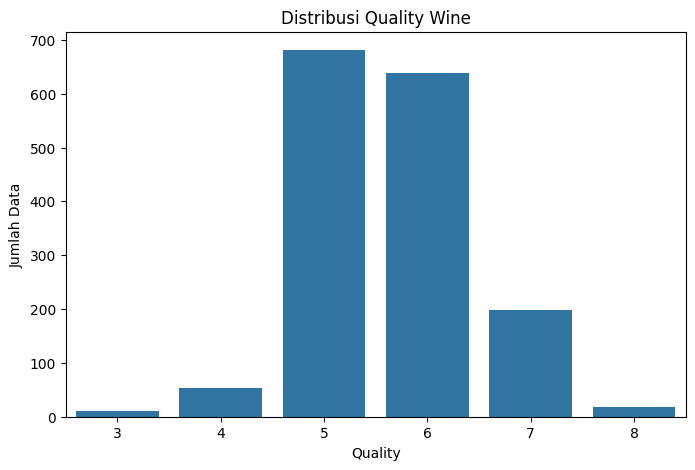

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(x='quality', data=df)

plt.title('Distribusi Quality Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

Melihat Korelasi Antar Fitur

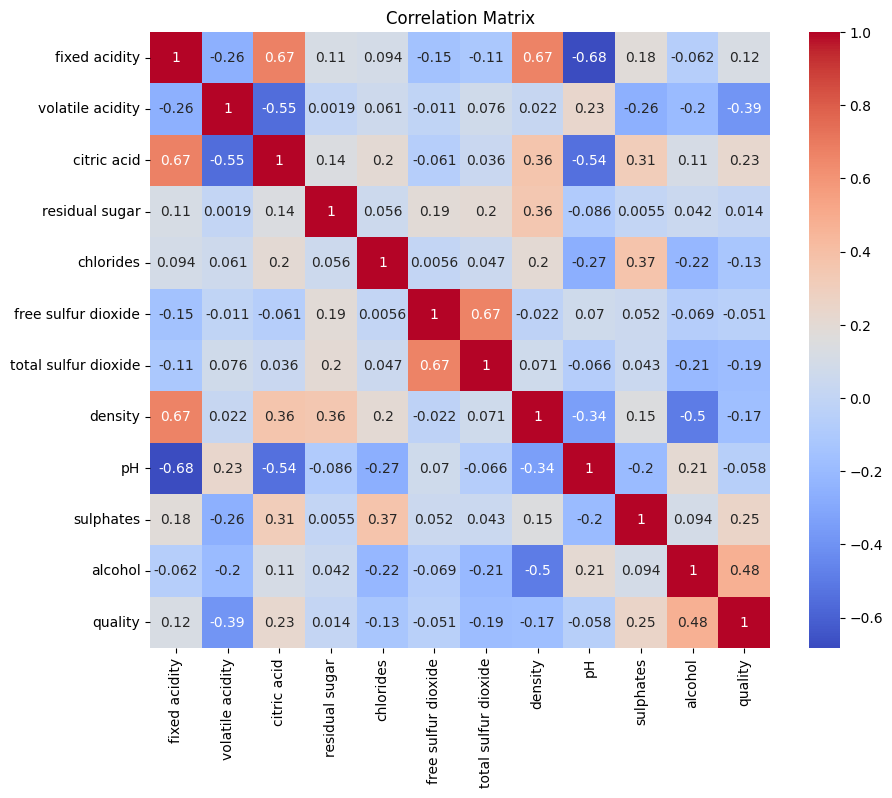

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# Select only numeric columns for correlation calculation
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

Visualisasi analisis Alcohol terhadap Quality

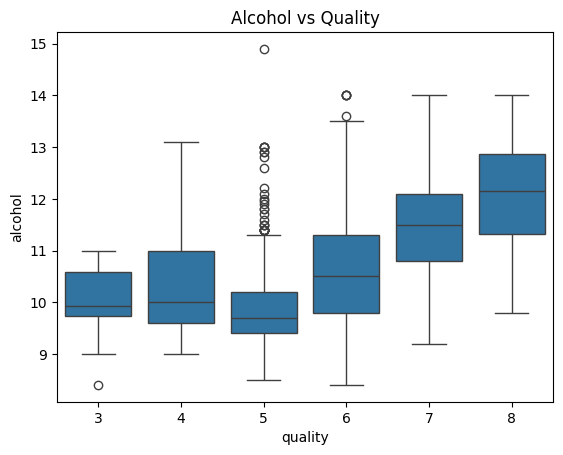

In [ ]:
sns.boxplot(x='quality', y='alcohol', data=df)

plt.title('Alcohol vs Quality')
plt.show()

Pairplot Antar Variabel

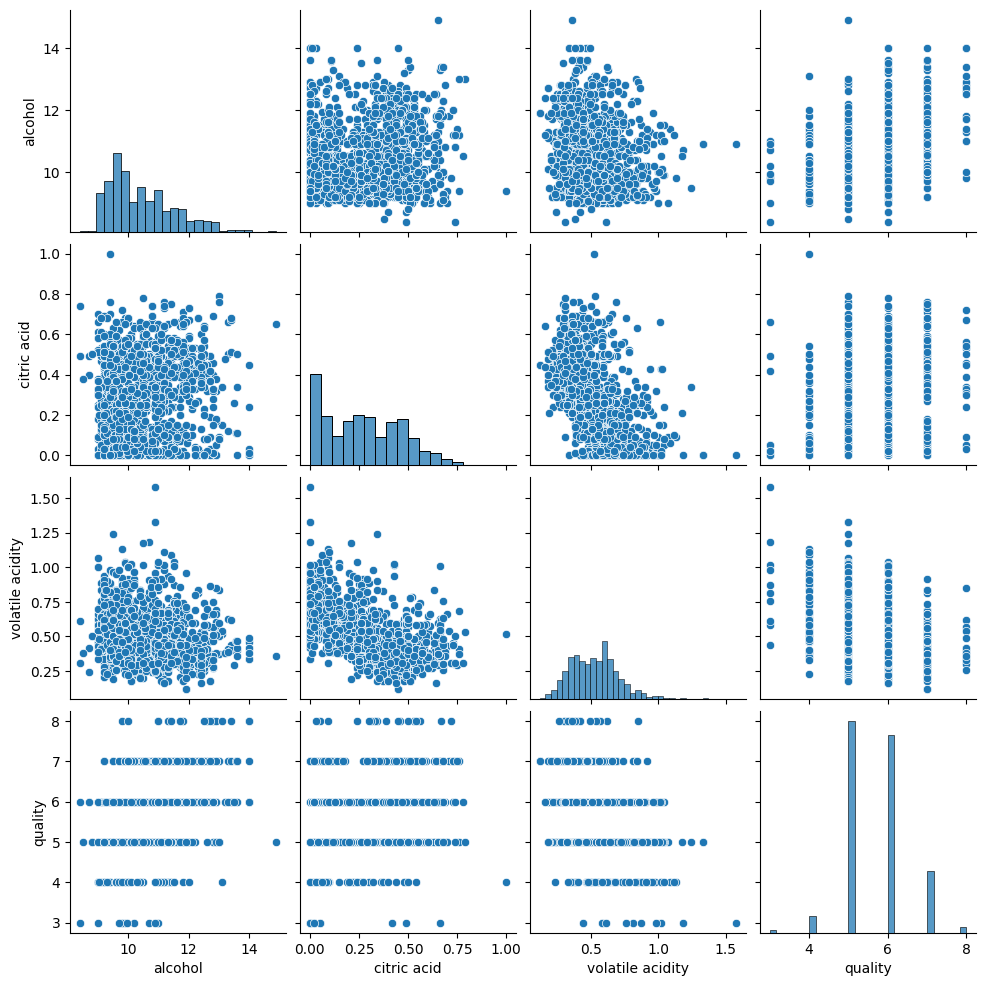

In [22]:
sns.pairplot(df[['alcohol',
                 'citric acid',
                 'volatile acidity',
                 'quality']])

plt.show()

Scatter Plot Alcohol dan Quality

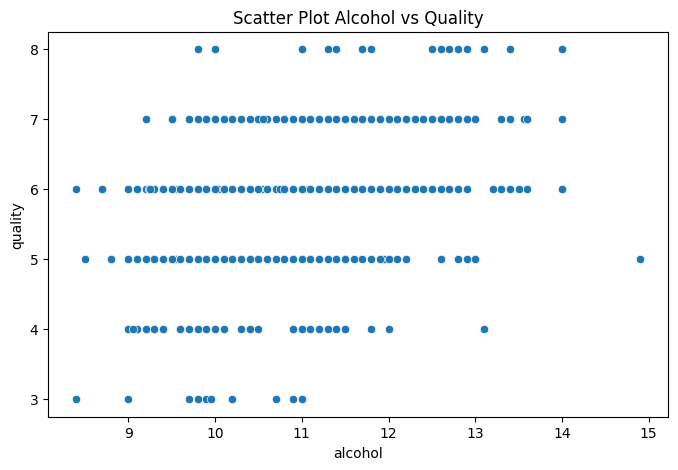

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='alcohol',
                y='quality',
                data=df)

plt.title('Scatter Plot Alcohol vs Quality')

plt.show()

Visualisasi Citric Acid terhadap Quality

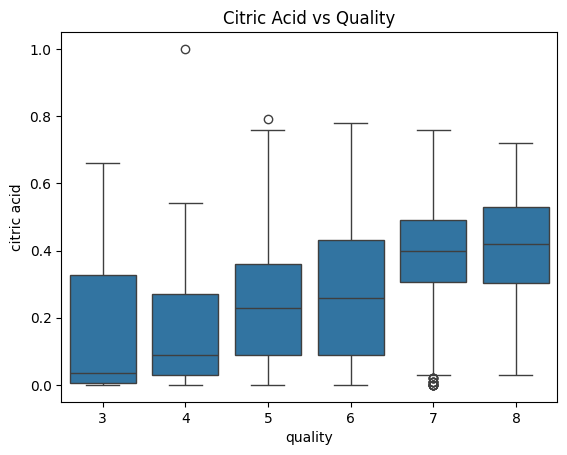

In [ ]:
sns.boxplot(x='quality', y='citric acid', data=df)

plt.title('Citric Acid vs Quality')
plt.show()

Deteksi Outlier

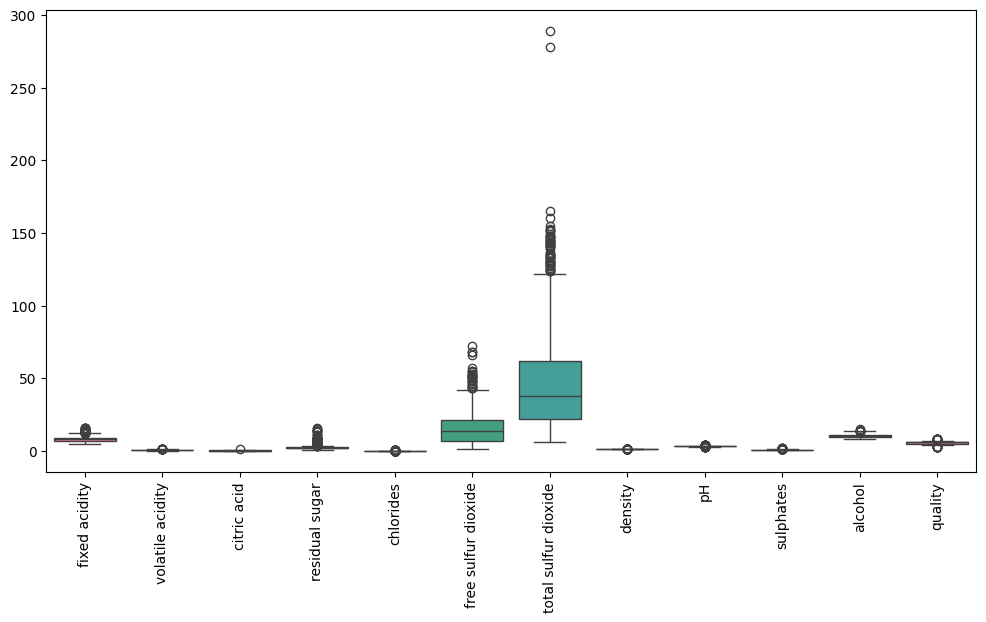

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

visualisasi histogram

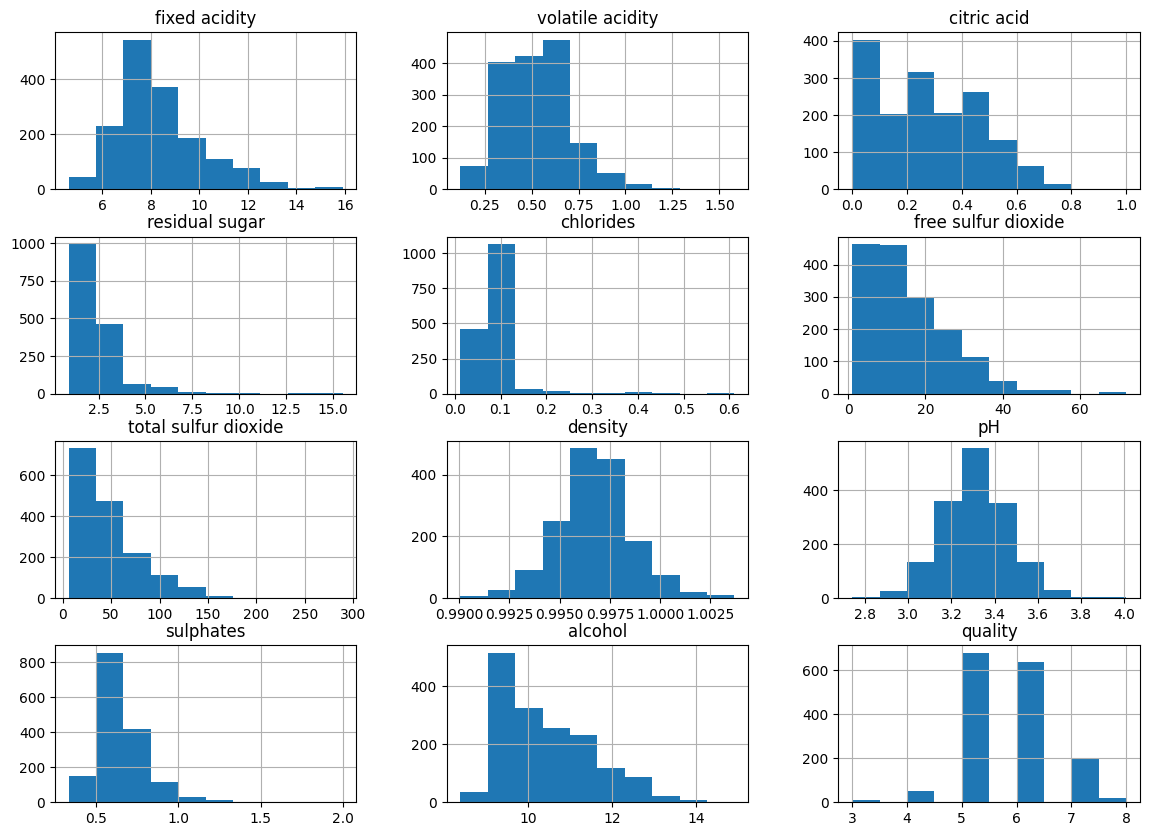

In [17]:
df.hist(figsize=(14,10))
plt.show()

Visualisasi Residual Sugar

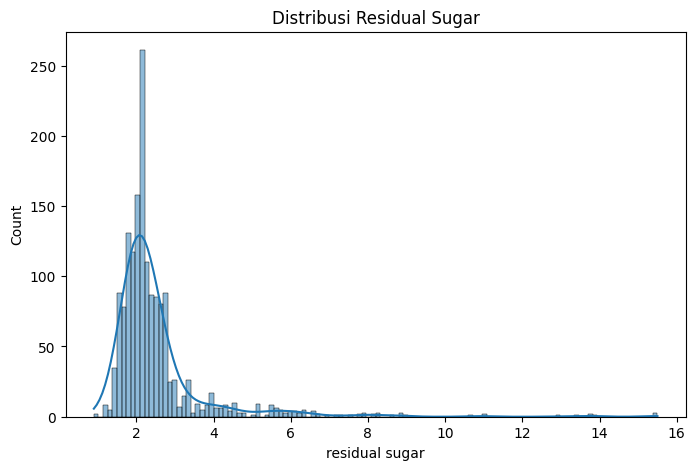

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df['residual sugar'],
    kde=True
)

plt.title('Distribusi Residual Sugar')

plt.show()